# Autoencoder Experiments - Single Run Per Model

This notebook runs one full training + analysis workflow for each model.


In [1]:
from autoencoder_workflow import AutoencoderWorkflow


In [3]:
# Common config
DATA_DIR = '/home/marmatt/Documents/projects/BRAF/myWork/workflowJanuary2026/Results/activation_segments/fitted_mda/'
BASE_OUTPUT_DIR = 'Results/run_trial_BRAFActivationLoop_postalign_checkpoint0'
ATOM_SELECTION = ['CA']
MAX_EPOCHS = 32
PATIENCE = 32


## Small Autoencoder (Single Run)


In [4]:
wf_small = AutoencoderWorkflow(
    folder_name=DATA_DIR,
    output_base_dir=BASE_OUTPUT_DIR,
    manual_seed=25,
    batch_size=8,
)
wf_small.prepare_data(atom_selection=ATOM_SELECTION)
wf_small.set_output_subfolder('small_single_run', create=True)
wf_small.train(max_epochs=MAX_EPOCHS, patience=PATIENCE)


Dataset shape: torch.Size([2523, 27, 3])
mean: 110.1438756714563
 std: 20.30379482405781
Loaded 2523 structures
[output] model=Small_AutoEncoder output=Results/run_trial_BRAFActivationLoop_postalign_checkpoint0/small_single_run
device: cuda
[train] model=Small_AutoEncoder output=Results/run_trial_BRAFActivationLoop_postalign_checkpoint0/small_single_run
epoch              : 0
train_mse_loss     : 0.108377
train_loss         : 0.108377
valid_mse_loss     : 0.035202
valid_loss         : 0.035202
train_seconds      : 1.600871
valid_seconds      : 0.066078
checkpoint_seconds : 0.125573
total_seconds      : 1.792522

epoch              : 1
train_mse_loss     : 0.024869
train_loss         : 0.024869
valid_mse_loss     : 0.020706
valid_loss         : 0.020706
train_seconds      : 1.242591
valid_seconds      : 0.053851
checkpoint_seconds : 0.118669
total_seconds      : 1.415112

epoch              : 2
train_mse_loss     : 0.018702
train_loss         : 0.018702
valid_mse_loss     : 0.017347
val

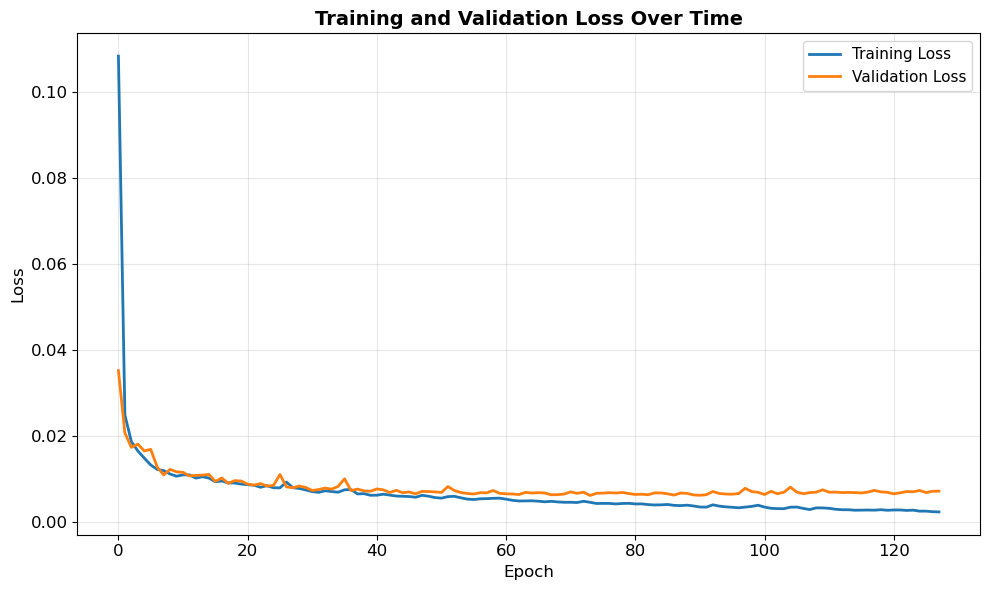

Final training loss: 0.002330
Final validation loss: 0.007163
Best validation loss: 0.006156 (epoch 73)


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Training and Validation Loss Over Time'}, xlabel='Epoch', ylabel='Loss'>,
      train_mse_loss  train_loss  valid_mse_loss  valid_loss  epoch  \
 0          0.108377    0.108377        0.035202    0.035202      0   
 1          0.024869    0.024869        0.020706    0.020706      1   
 2          0.018702    0.018702        0.017347    0.017347      2   
 3          0.016530    0.016530        0.018104    0.018104      3   
 4          0.014860    0.014860        0.016526    0.016526      4   
 ..              ...         ...             ...         ...    ...   
 123        0.002749    0.002749        0.007021    0.007021    123   
 124        0.002511    0.002511        0.007325    0.007325    124   
 125        0.002515    0.002515        0.006829    0.006829    125   
 126        0.002381    0.002381        0.007133    0.007133    126   
 127        0.002330    0.002330        0.007163    0.007163    127   
 
      tra

In [5]:
wf_small.plot_training_history(log_filename='log.dat')

In [6]:
# Setup and run analysis
wf_small.setup_analysis(atom_selection=ATOM_SELECTION)
wf_small.extract_dataset()
wf_small.decode_structures()
wf_small.calculate_errors(save_prefix='_small_checkpoint')
wf_small.scan_error_landscape(grid_size=30, save_prefix='_small_checkpoint')
wf_small.extract_encoded_coordinates(save_prefix='_small_checkpoint')


[analysis] model=Small_AutoEncoder output=Results/run_trial_BRAFActivationLoop_postalign_checkpoint0/small_single_run


encoding training: 284it [00:00, 1340.38it/s]
Generating pdb files: 100%|██████████| 2271/2271 [00:01<00:00, 1672.20it/s]
encoding validation: 32it [00:00, 1144.08it/s]
Generating pdb files: 100%|██████████| 252/252 [00:00<00:00, 1848.22it/s]
Decoding training: 284it [00:00, 1268.38it/s]
Decoding validation: 32it [00:00, 1227.67it/s]
Decoding grid: 113it [00:00, 1229.11it/s]
encoding grid_decoded: 113it [00:00, 1195.77it/s]
Decoding grid_decoded: 113it [00:00, 1377.34it/s]


Saved error violin plot to Results/run_trial_BRAFActivationLoop_postalign_checkpoint0/small_single_run/ErrorViolinsTrainVsValid_small.png


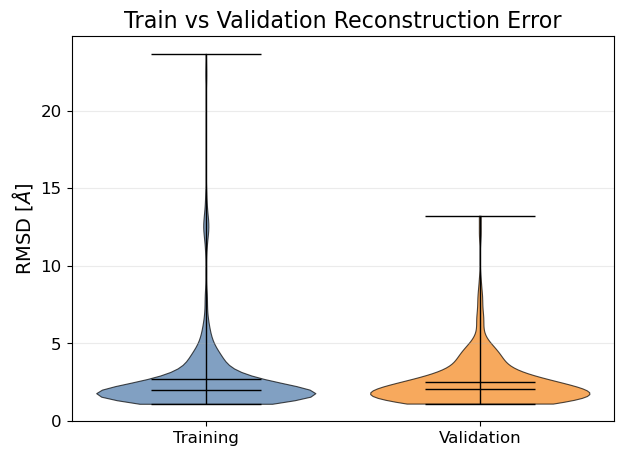

Saved RMSD landscape projection to Results/run_trial_BRAFActivationLoop_postalign_checkpoint0/small_single_run/RMSDlandscapesOnePlot_small.png


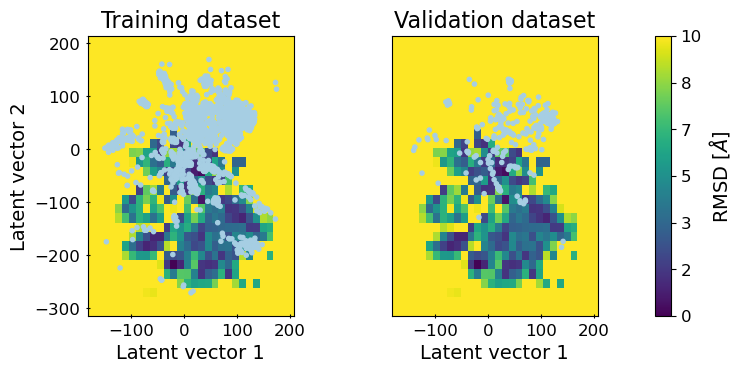

(<Figure size 800x800 with 3 Axes>,
 (<Axes: title={'center': 'Training dataset'}, xlabel='Latent vector 1', ylabel='Latent vector 2'>,
  <Axes: title={'center': 'Validation dataset'}, xlabel='Latent vector 1'>))

In [7]:
# Classic one-run visualizations
wf_small.plot_error_violins(output_file='ErrorViolinsTrainVsValid_small.png', save_prefix='_small_checkpoint')
wf_small.plot_rmsd_landscape_projection(output_file='RMSDlandscapesOnePlot_small.png', save_prefix='_small_checkpoint')


## 2D CNN Autoencoder (Single Run)


In [8]:
wf_cnn2d = AutoencoderWorkflow(
    folder_name=DATA_DIR,
    output_base_dir=BASE_OUTPUT_DIR,
    manual_seed=25,
    batch_size=8,
)
wf_cnn2d.prepare_data(atom_selection=ATOM_SELECTION)
wf_cnn2d.train_cnn2d_ae(
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    latent_dim=2,
    output_subfolder='cnn2d_single_run',
)


Dataset shape: torch.Size([2523, 27, 3])
mean: 110.1438756714563
 std: 20.30379482405781
Loaded 2523 structures
[output] model=Small_AutoEncoder output=Results/run_trial_BRAFActivationLoop_postalign_checkpoint0/cnn2d_single_run
device: cuda
VAE: dims=[27, 13, 6], channels=[1, 32, 64]
[train] model=AutoEncoder output=Results/run_trial_BRAFActivationLoop_postalign_checkpoint0/cnn2d_single_run
epoch              : 0
train_mse_loss     : 0.055899
train_loss         : 0.055899
valid_mse_loss     : 0.015470
valid_loss         : 0.015470
train_seconds      : 0.359217
valid_seconds      : 0.016738
checkpoint_seconds : 0.003166
total_seconds      : 0.379121

epoch              : 1
train_mse_loss     : 0.015613
train_loss         : 0.015613
valid_mse_loss     : 0.012825
valid_loss         : 0.012825
train_seconds      : 0.308808
valid_seconds      : 0.014115
checkpoint_seconds : 0.003053
total_seconds      : 0.325976

epoch              : 2
train_mse_loss     : 0.013619
train_loss         : 0.01

KeyboardInterrupt: 

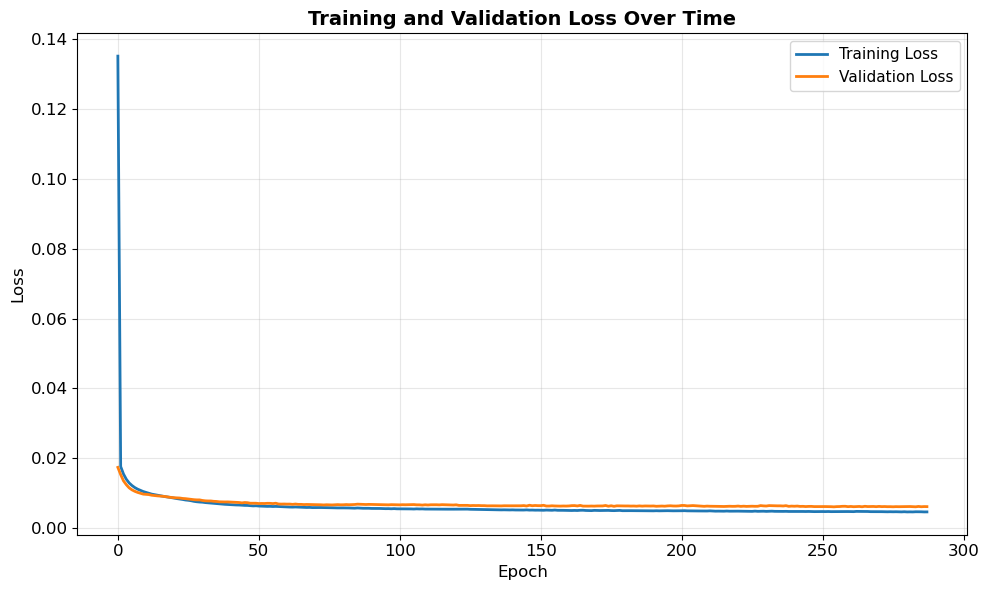

Final training loss: 0.004587
Final validation loss: 0.006097
Best validation loss: 0.006037 (epoch 254)


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Training and Validation Loss Over Time'}, xlabel='Epoch', ylabel='Loss'>,
      train_mse_loss  train_loss  valid_mse_loss  valid_loss  epoch  \
 0          0.135190    0.135190        0.017343    0.017343      0   
 1          0.017584    0.017584        0.015279    0.015279      1   
 2          0.015430    0.015430        0.013483    0.013483      2   
 3          0.013939    0.013939        0.012376    0.012376      3   
 4          0.012890    0.012890        0.011484    0.011484      4   
 ..              ...         ...             ...         ...    ...   
 283        0.004626    0.004626        0.006046    0.006046    283   
 284        0.004625    0.004625        0.006151    0.006151    284   
 285        0.004615    0.004615        0.006066    0.006066    285   
 286        0.004580    0.004580        0.006113    0.006113    286   
 287        0.004587    0.004587        0.006097    0.006097    287   
 
      tra

In [ ]:
wf_cnn2d.plot_training_history(log_filename='log.dat')

In [ ]:
# Setup and run analysis
wf_cnn2d.setup_analysis(atom_selection=ATOM_SELECTION)
wf_cnn2d.extract_dataset()
wf_cnn2d.decode_structures()
wf_cnn2d.calculate_errors(save_prefix='_cnn2d_checkpoint')
wf_cnn2d.scan_error_landscape(grid_size=30, save_prefix='_cnn2d_checkpoint')
wf_cnn2d.extract_encoded_coordinates(save_prefix='_cnn2d_checkpoint')


[analysis] model=AutoEncoder output=Results/run_trial_BRAFActivationLoop_postalign_checkpoint0/cnn2d_single_run


encoding training: 284it [00:00, 4545.46it/s]
Generating pdb files: 100%|██████████| 2271/2271 [00:01<00:00, 1783.90it/s]
encoding validation: 32it [00:00, 3962.50it/s]
Generating pdb files: 100%|██████████| 252/252 [00:00<00:00, 1852.90it/s]
Decoding training: 284it [00:00, 7105.89it/s]
Decoding validation: 32it [00:00, 6502.80it/s]
Decoding grid: 113it [00:00, 7215.92it/s]
encoding grid_decoded: 113it [00:00, 3892.32it/s]
Decoding grid_decoded: 113it [00:00, 7039.93it/s]


Saved error violin plot to Results/run_trial_BRAFActivationLoop_postalign_checkpoint0/cnn2d_single_run/ErrorViolinsTrainVsValid_cnn2d.png


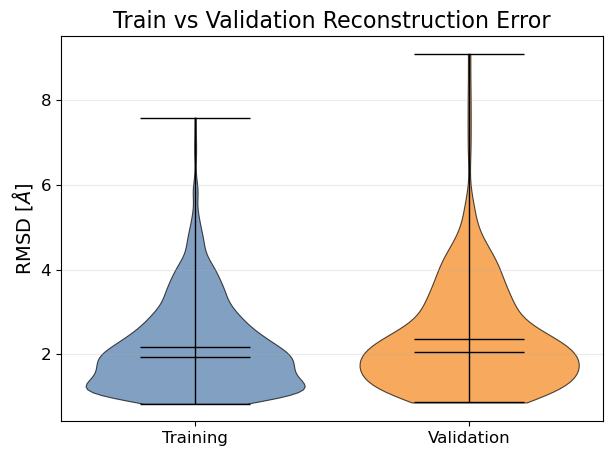

Saved RMSD landscape projection to Results/run_trial_BRAFActivationLoop_postalign_checkpoint0/cnn2d_single_run/RMSDlandscapesOnePlot_cnn2d.png


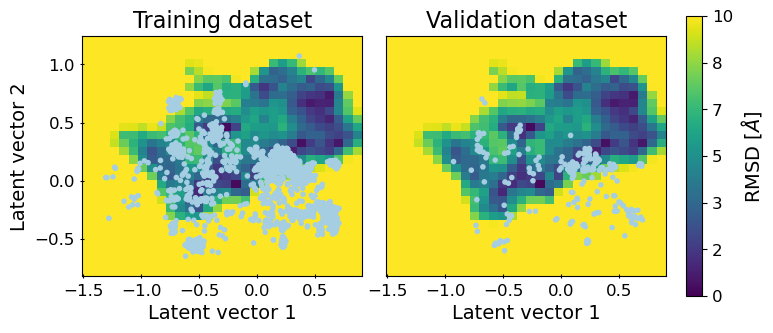

(<Figure size 800x800 with 3 Axes>,
 (<Axes: title={'center': 'Training dataset'}, xlabel='Latent vector 1', ylabel='Latent vector 2'>,
  <Axes: title={'center': 'Validation dataset'}, xlabel='Latent vector 1'>))

In [ ]:
# Classic one-run visualizations
wf_cnn2d.plot_error_violins(output_file='ErrorViolinsTrainVsValid_cnn2d.png', save_prefix='_cnn2d_checkpoint')
wf_cnn2d.plot_rmsd_landscape_projection(output_file='RMSDlandscapesOnePlot_cnn2d.png', save_prefix='_cnn2d_checkpoint')


## Writhe CNN2D Autoencoder (Single Run)

In [1]:
from autoencoder_workflow import AutoencoderWorkflow

In [2]:
# Common config
DATA_DIR = '/home/marmatt/Documents/projects/BRAF/myWork/workflowJanuary2026/Results/activation_segments/fitted_mda/'
BASE_OUTPUT_DIR = 'Results/run_trial_BRAFActivationLoop_postalign_checkpoint0'
ATOM_SELECTION = ['CA']
MAX_EPOCHS = 32
PATIENCE = 32

In [3]:
from autoencoder_workflow import AutoencoderWorkflow

wf_writhe = AutoencoderWorkflow(
    folder_name=DATA_DIR,
    output_base_dir=BASE_OUTPUT_DIR,
    manual_seed=25,
    batch_size=8,
)
wf_writhe.prepare_data(atom_selection=ATOM_SELECTION)
wf_writhe.train_wrCNN2D_ae(
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    latent_dim=2,
    output_subfolder='wrCNN2D_ae',
)

Dataset shape: torch.Size([2523, 27, 3])
mean: 110.1438756714563
 std: 20.30379482405781
Loaded 2523 structures
[output] model=Small_AutoEncoder output=Results/run_trial_BRAFActivationLoop_postalign_checkpoint0/wrCNN2D_ae
device: cuda
wrCNN2D: dims=[26, 13, 6], channels=[1, 32, 64]
Pre-computed writhe matrices: torch.Size([2523, 1, 26, 26]), train=torch.Size([2271, 1, 26, 26]), valid=torch.Size([252, 1, 26, 26])
[train] model=AutoEncoder output=Results/run_trial_BRAFActivationLoop_postalign_checkpoint0/wrCNN2D_ae
epoch              : 0
train_writhe_loss  : 0.008057
train_loss         : 0.008057
valid_writhe_loss  : 0.000072
valid_loss         : 0.000072
train_seconds      : 0.564562
valid_seconds      : 0.015043
checkpoint_seconds : 0.004343
total_seconds      : 0.583948

epoch              : 1
train_writhe_loss  : 0.000065
train_loss         : 0.000065
valid_writhe_loss  : 0.000065
valid_loss         : 0.000065
train_seconds      : 0.299114
valid_seconds      : 0.013026
checkpoint_sec

In [4]:
wf_writhe.plot_training_history(output_file='training_history_wrCNN2D.png')

Saved training history plot to Results/run_trial_BRAFActivationLoop_postalign_checkpoint0/wrCNN2D_ae/training_history_wrCNN2D.png
Final training loss: 0.000010
Final validation loss: 0.000013
Best validation loss: 0.000013 (epoch 502)


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Training and Validation Loss Over Time'}, xlabel='Epoch', ylabel='Loss'>,
      train_writhe_loss  train_loss  valid_writhe_loss  valid_loss  epoch  \
 0             0.008057    0.008057           0.000072    0.000072      0   
 1             0.000065    0.000065           0.000065    0.000065      1   
 2             0.000061    0.000061           0.000076    0.000076      2   
 3             0.000067    0.000067           0.000070    0.000070      3   
 4             0.000071    0.000071           0.000062    0.000062      4   
 ..                 ...         ...                ...         ...    ...   
 539           0.000010    0.000010           0.000013    0.000013    539   
 540           0.000010    0.000010           0.000013    0.000013    540   
 541           0.000010    0.000010           0.000013    0.000013    541   
 542           0.000010    0.000010           0.000013    0.000013    542   
 543           0

In [5]:
import os

gif_path = os.path.join(wf_writhe.output_base_dir, 'writhe_reconstruction_train.gif')
wf_writhe.trainer.generate_reconstruction_gif(gif_path, dataset='train', fps=3)

from IPython.display import Image, display
display(Image(filename=gif_path))

imageio is unavailable; saved PNG frames instead to Results/run_trial_BRAFActivationLoop_postalign_checkpoint0/wrCNN2D_ae/writhe_reconstruction_train_frames (2271 frames)


FileNotFoundError: [Errno 2] No such file or directory: 'Results/run_trial_BRAFActivationLoop_postalign_checkpoint0/wrCNN2D_ae/writhe_reconstruction_train.gif'

In [ ]:
wf_writhe.setup_analysis(atom_selection=ATOM_SELECTION)
wf_writhe.extract_encoded_coordinates(save_prefix='_wrCNN2D_checkpoint')